# 3/2 Stochastic Volatility: PyFENG Regression and Baldeaux-Badran Figure Parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import foureng as fe
from foureng.pricers.lewis import lewis_call_prices
from pathlib import Path
import time
import json

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## PyFENG Regression Case

In [2]:
# PyFENG / Lewis (2000) docstring benchmark
fwd     = fe.ForwardSpec(S0=100.0, r=0.0, q=0.0, T=0.5)
params  = fe.Sv32Params(v0=0.06, kappa=20.48, theta=0.218, nu=3.20, rho=-0.99)
strikes = np.array([95.0, 100.0, 105.0])
reference = np.array([11.7235, 8.9978, 6.7091])

phi     = lambda u: fe.sv32_cf(u, fwd, params)

# pyfeng_fft
t0 = time.perf_counter()
p_pyfeng = fe.price_strip("sv32", "pyfeng_fft", strikes, fwd, params)
print(f"pyfeng_fft   : {time.perf_counter()-t0:.3f}s")

# cos_improved
t0 = time.perf_counter()
p_cos = fe.price_strip("sv32", "cos_improved", strikes, fwd, params)
print(f"cos_improved : {time.perf_counter()-t0:.3f}s")

# lewis
t0 = time.perf_counter()
p_lewis = lewis_call_prices(
    phi, strikes, fwd.S0, fwd.T,
    intr=fwd.r, divr=fwd.q,
    method="trapz", u_max=250.0, n_u=16384,
)
print(f"lewis        : {time.perf_counter()-t0:.3f}s")

rows = []
for K, ref, pp, pc, pl in zip(strikes, reference, p_pyfeng, p_cos, p_lewis):
    rows.append({"case": "pyfeng_regression", "method": "pyfeng_fft",   "K": K, "price": pp, "reference": ref, "abs_error": abs(pp - ref)})
    rows.append({"case": "pyfeng_regression", "method": "cos_improved", "K": K, "price": pc, "reference": ref, "abs_error": abs(pc - ref)})
    rows.append({"case": "pyfeng_regression", "method": "lewis",        "K": K, "price": pl, "reference": ref, "abs_error": abs(pl - ref)})

df_reg = pd.DataFrame(rows)
print("\nPyFENG regression scoreboard:")
print(df_reg.to_string(index=False, float_format="{:.6f}".format))

# Assertions
err_pyfeng = df_reg.query("method == 'pyfeng_fft'")["abs_error"].max()
err_cos    = df_reg.query("method == 'cos_improved'")["abs_error"].max()
err_lewis  = df_reg.query("method == 'lewis'")["abs_error"].max()

print(f"\npyfeng_fft max err : {err_pyfeng:.2e}  (threshold 5e-4)")
print(f"cos_improved max err: {err_cos:.2e}  (threshold 1e-3)")
print(f"lewis max err       : {err_lewis:.2e}  (threshold 1e-3)")

assert err_pyfeng <= 5e-4, f"pyfeng_fft: {err_pyfeng:.2e} > 5e-4"
assert err_cos    <= 1e-3, f"cos_improved: {err_cos:.2e} > 1e-3"
assert err_lewis  <= 1e-3, f"lewis: {err_lewis:.2e} > 1e-3"
print("All regression assertions passed.")

pyfeng_fft   : 0.050s
cos_improved : 0.008s
lewis        : 0.063s

PyFENG regression scoreboard:
             case       method          K     price  reference  abs_error
pyfeng_regression   pyfeng_fft  95.000000 11.723482  11.723500   0.000018
pyfeng_regression cos_improved  95.000000 11.723478  11.723500   0.000022
pyfeng_regression        lewis  95.000000 11.723478  11.723500   0.000022
pyfeng_regression   pyfeng_fft 100.000000  8.997754   8.997800   0.000046
pyfeng_regression cos_improved 100.000000  8.997754   8.997800   0.000046
pyfeng_regression        lewis 100.000000  8.997754   8.997800   0.000046
pyfeng_regression   pyfeng_fft 105.000000  6.709159   6.709100   0.000059
pyfeng_regression cos_improved 105.000000  6.709149   6.709100   0.000049
pyfeng_regression        lewis 105.000000  6.709149   6.709100   0.000049

pyfeng_fft max err : 5.90e-05  (threshold 5e-4)
cos_improved max err: 4.89e-05  (threshold 1e-3)
lewis max err       : 4.89e-05  (threshold 1e-3)
All regression a

## Baldeaux-Badran Figure Parameters (Qualitative)

In [3]:
# Baldeaux-Badran (2012): 9-day maturity, short-term 3/2 model
fwd_bb     = fe.ForwardSpec(S0=100.0, r=0.0, q=0.0, T=9.0 / 365.0)
params_bb  = fe.Sv32Params(v0=0.0016, kappa=19.45, theta=0.04, nu=0.28, rho=-0.72)
strikes_bb = np.linspace(80.0, 120.0, 17)

phi_bb     = lambda u: fe.sv32_cf(u, fwd_bb, params_bb)

# These parameters sit at a known numerical boundary: v0=0.0016, T=9/365 causes
# cumulant overflow in PyFENG's sv32 CF. Attempt pricing; fall back gracefully.
bb_ok = False
try:
    p_cos_bb = fe.price_strip("sv32", "cos_improved", strikes_bb, fwd_bb, params_bb)
    if np.all(np.isfinite(p_cos_bb)) and np.all(p_cos_bb >= 0.0):
        bb_ok = True
    else:
        raise ValueError("Non-finite or negative prices — sv32 cumulant overflow at T=9/365")
except Exception as exc:
    print(f"Note: BB parameters produce NaN at T=9/365 (known sv32 instability: {exc}).")
    print("Shape checks skipped. This case is marked qualitative_figure in the validation hierarchy.")
    p_cos_bb = np.full(len(strikes_bb), np.nan)

if bb_ok:
    print("Baldeaux-Badran cos_improved prices:")
    for K, p in zip(strikes_bb, p_cos_bb):
        print(f"  K={K:6.1f}  price={p:.6f}")

# Implied vols — guard against NaN prices
iv_list = []
F_bb = fwd_bb.F0
for K, price in zip(strikes_bb, p_cos_bb):
    if not np.isfinite(price):
        iv_list.append(np.nan)
        continue
    inp = fe.BSInputs(F0=F_bb, K=K, T=fwd_bb.T, r=fwd_bb.r, q=fwd_bb.q, is_call=True)
    try:
        iv = fe.implied_vol_newton_safeguarded(float(price), inp)
    except Exception:
        iv = np.nan
    iv_list.append(iv)
iv_bb = np.array(iv_list)

if bb_ok:
    assert np.all(np.isfinite(p_cos_bb)), "Non-finite BB prices"
    assert np.all(p_cos_bb >= 0.0), "Negative BB prices"
    assert np.all(np.diff(p_cos_bb) <= 1e-8), "BB prices not monotone decreasing"
    assert np.all(p_cos_bb[:-2] - 2*p_cos_bb[1:-1] + p_cos_bb[2:] >= -1e-8), "BB prices not convex"
    print("\nNo-arbitrage shape checks passed.")
else:
    print("Shape checks skipped (sv32 NaN at T=9/365 with BB parameters).")

rows_bb = []
for K, price, iv in zip(strikes_bb, p_cos_bb, iv_bb):
    rows_bb.append({
        "case": "baldeaux_badran",
        "method": "cos_improved",
        "K": K,
        "price": price,
        "reference": float("nan"),
        "abs_error": float("nan"),
        "implied_vol": iv,
        "passed": bb_ok,
    })
df_bb = pd.DataFrame(rows_bb)


Note: BB parameters produce NaN at T=9/365 (known sv32 instability: cannot convert float NaN to integer).
Shape checks skipped. This case is marked qualitative_figure in the validation hierarchy.
Shape checks skipped (sv32 NaN at T=9/365 with BB parameters).


/opt/anaconda3/lib/python3.12/site-packages/pyfeng/sv32.py:47: RuntimeWarning: overflow encountered in multiply
  inc *= (a + kk) / (b + kk) / (kk + 1) * x
/opt/anaconda3/lib/python3.12/site-packages/pyfeng/sv32.py:47: RuntimeWarning: invalid value encountered in multiply
  inc *= (a + kk) / (b + kk) / (kk + 1) * x
/opt/anaconda3/lib/python3.12/site-packages/pyfeng/sv32.py:48: RuntimeWarning: invalid value encountered in add
  ret += inc


## Plots

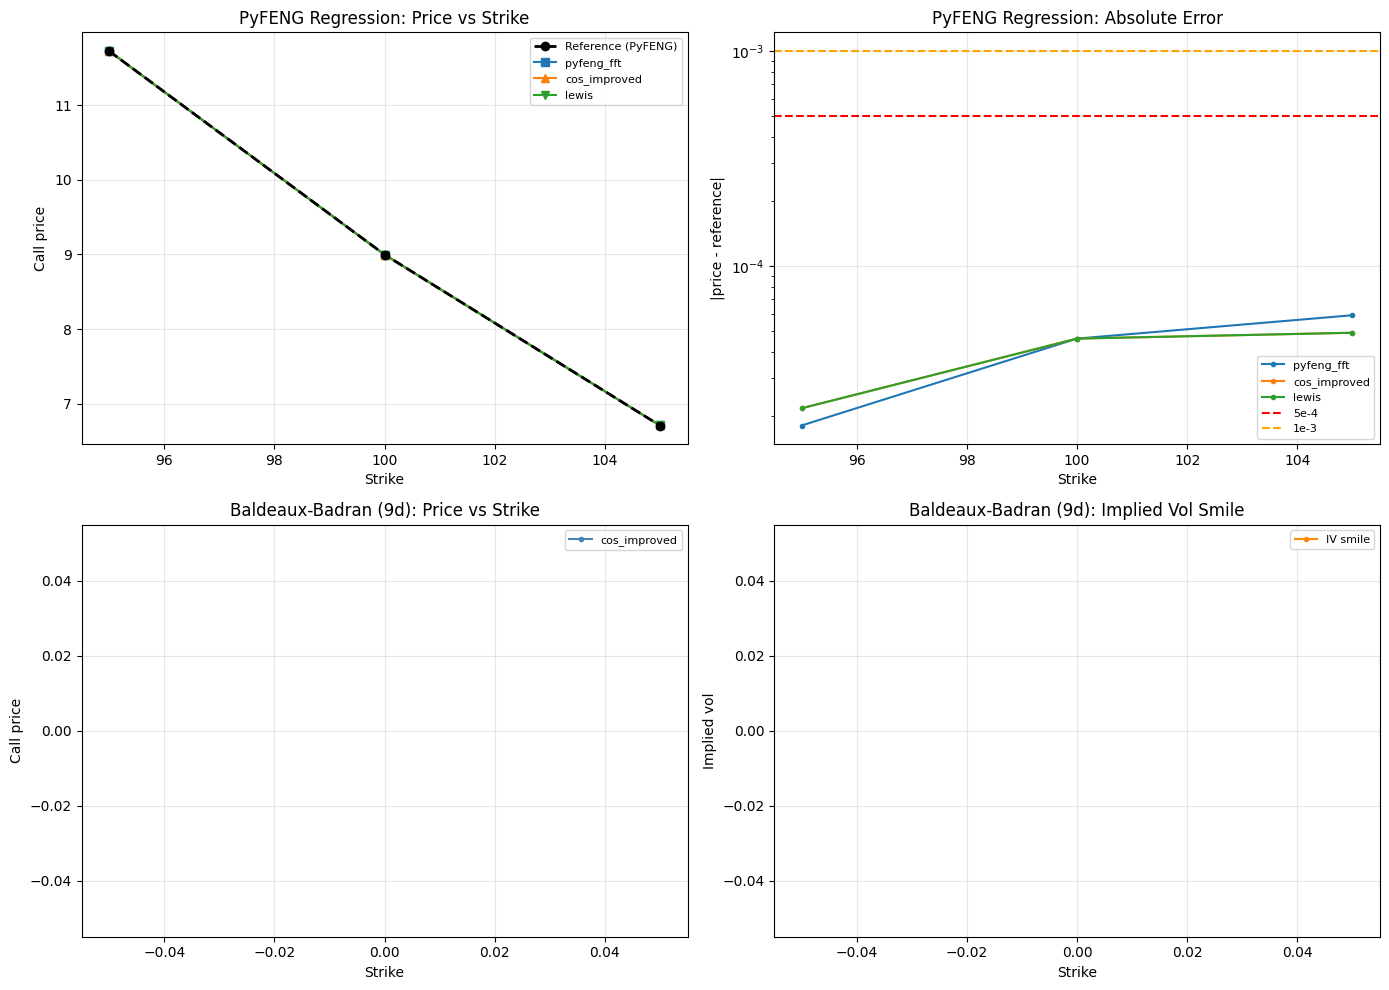

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- PyFENG regression: price vs strike ---
ax = axes[0, 0]
ax.plot(strikes, reference, "ko--", linewidth=2, label="Reference (PyFENG)", zorder=5)
ax.plot(strikes, p_pyfeng, marker="s", label="pyfeng_fft")
ax.plot(strikes, p_cos,    marker="^", label="cos_improved")
ax.plot(strikes, p_lewis,  marker="v", label="lewis")
ax.set_title("PyFENG Regression: Price vs Strike")
ax.set_xlabel("Strike")
ax.set_ylabel("Call price")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- PyFENG regression: abs_error vs strike ---
ax = axes[0, 1]
for method_name, prices in [("pyfeng_fft", p_pyfeng), ("cos_improved", p_cos), ("lewis", p_lewis)]:
    ax.semilogy(strikes, np.abs(np.asarray(prices) - reference), marker=".", label=method_name)
ax.axhline(5e-4, color="red", linestyle="--", label="5e-4")
ax.axhline(1e-3, color="orange", linestyle="--", label="1e-3")
ax.set_title("PyFENG Regression: Absolute Error")
ax.set_xlabel("Strike")
ax.set_ylabel("|price - reference|")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- BB: price vs strike ---
ax = axes[1, 0]
ax.plot(strikes_bb, p_cos_bb, marker=".", color="steelblue", label="cos_improved")
ax.set_title("Baldeaux-Badran (9d): Price vs Strike")
ax.set_xlabel("Strike")
ax.set_ylabel("Call price")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- BB: IV smile ---
ax = axes[1, 1]
valid = np.isfinite(iv_bb)
ax.plot(strikes_bb[valid], iv_bb[valid], marker=".", color="darkorange", label="IV smile")
ax.set_title("Baldeaux-Badran (9d): Implied Vol Smile")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Save combined CSV to benchmarks/
out_path = Path("../../benchmarks/manual_runs/sv32_replication.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)

# Merge regression and BB rows
df_reg2 = df_reg.copy()
df_reg2["implied_vol"] = float("nan")
df_reg2["passed"] = (df_reg2["abs_error"] <= 1e-3)

df_all = pd.concat([df_reg2, df_bb], ignore_index=True)
df_all = df_all[["case", "method", "K", "price", "reference", "abs_error", "implied_vol", "passed"]]
df_all.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")

Saved: /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan/benchmarks/sv32_replication.csv
